In [1]:
# Instal library yfinance jika belum ada
!pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Library berhasil diimpor!")

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\USER\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Library berhasil diimpor!


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Tentukan Simbol dan Ambil Data Harian (5 Tahun)
symbol = 'SOL-USD'
data_raw = yf.download(symbol, period='5y', interval='1d')
df = data_raw[['Open', 'High', 'Low', 'Close']].dropna().copy()

# 2. HITUNG INDIKATOR RSI (Periode 14)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# 3. HITUNG INDIKATOR MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# 4. HITUNG BOLLINGER BANDS (Support & Resistance Dinamis)
ma20 = df['Close'].rolling(window=20).mean()
std20 = df['Close'].rolling(window=20).std()
df['BB_Upper'] = ma20 + (2 * std20) # Resistance
df['BB_Lower'] = ma20 - (2 * std20) # Support

# Hapus baris yang kosong akibat perhitungan moving average
df = df.dropna()

print("=== STATUS DATA MULTIVARIATE TINGKAT TINGGI ===")
print(f"Total Fitur Sekarang: {df.shape[1]} Kolom")
print(f"Daftar Fitur Resmi: {df.columns.tolist()}")
print(f"Total Baris Data Latih: {len(df)}")
df.tail()

[*********************100%***********************]  1 of 1 completed

=== STATUS DATA MULTIVARIATE TINGKAT TINGGI ===
Total Fitur Sekarang: 9 Kolom
Daftar Fitur Resmi: [('Open', 'SOL-USD'), ('High', 'SOL-USD'), ('Low', 'SOL-USD'), ('Close', 'SOL-USD'), ('RSI', ''), ('MACD', ''), ('MACD_Signal', ''), ('BB_Upper', ''), ('BB_Lower', '')]
Total Baris Data Latih: 1808


Price,Open,High,Low,Close,RSI,MACD,MACD_Signal,BB_Upper,BB_Lower
Ticker,SOL-USD,SOL-USD,SOL-USD,SOL-USD,,,,,
Date,,,,,,,,,
2026-06-23,71.907524,71.921997,68.339401,69.643684,59.675615,-1.726814,-2.578963,75.925208,61.579630
2026-06-24,69.643677,70.226425,64.830978,67.982498,60.022755,-1.837204,-2.430611,75.896667,61.534529
2026-06-25,67.982254,69.436890,64.418365,67.574089,51.807861,-1.935335,-2.331556,75.695698,62.144212
2026-06-26,67.574089,73.703346,65.920654,71.835381,60.176726,-1.650231,-2.195291,75.500184,63.304284
2026-06-27,71.832008,72.321915,71.351868,71.550003,55.782130,-1.430818,-2.042397,75.652104,63.676302


In [3]:
from sklearn.preprocessing import MinMaxScaler

# 1. Normalisasi untuk semua 9 kolom sekaligus
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# 2. Tentukan Window Jangka Pendek (24 Hari)
prediction_window = 24

# 3. Pembagian Data Latih (80%) dan Uji (20%)
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size - prediction_window:]

# 4. Fungsi Sequence untuk 9 Fitur
def create_advanced_sequences(data, window):
    x, y = [], []
    for i in range(window, len(data)):
        x.append(data[i-window:i, :]) # Mengambil 9 fitur sebagai input (OHLC + RSI + MACD + BB)
        y.append(data[i, 3])          # Target tetap menebak harga Close (Indeks ke-3)
    return np.array(x), np.array(y)

x_train, y_train = create_advanced_sequences(train_data, prediction_window)
x_test, y_test = create_advanced_sequences(test_data, prediction_window)

print(f"Bentuk data baru x_train: {x_train.shape}") # Output: (Sampel, 24, 9)
print("Data Preprocessing 9 Fitur Berhasil Selesai!")

Bentuk data baru x_train: (1422, 24, 9)
Data Preprocessing 9 Fitur Berhasil Selesai!


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

# Layer 1: Perhatikan angka 9 di input_shape
model.add(LSTM(units=64, return_sequences=True, input_shape=(x_train.shape[1], 9)))
model.add(Dropout(0.2))

# Layer 2
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

# Fully Connected Layers
model.add(Dense(units=32))
model.add(Dense(units=1)) # Output tunggal (Harga Close esok hari)

model.compile(optimizer='adam', loss='mean_squared_error')

print("Memulai Training Model LSTM Kuantitatif...")
model.fit(x_train, y_train, batch_size=32, epochs=50, verbose=1)
print("Training Selesai dengan Sempurna!")

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Memulai Training Model LSTM Kuantitatif...
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0285
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0051
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0047
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0042
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0041
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0036
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0033
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0033
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0032
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0031
Epoch 12/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0029
Epoch 13/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0027
Epoch 14/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0024
Epoch 15/50
45/45 ━━━━━━━━━━

=== EVALUASI HISTORIS (9 FITUR) ===
MAE  : $4.69
RMSE : $6.63
MAPE : 3.46% (Tingkat Akurasi: 96.54%)

=== HASIL RAMALAN HARGA MASA DEPAN ===
👉 TARGET HARGA CLOSE SOLANA (1 HARI KE DEPAN): $69.08
Dianalisis pada waktu rilis: 2026-06-28 18:33 WIB




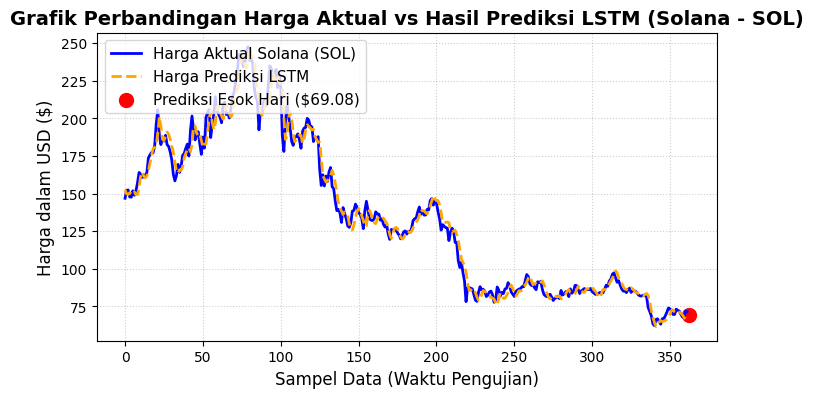

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime, timedelta, timezone
import matplotlib.pyplot as plt
import numpy as np

# --- PART 1: EVALUASI KESALAHAN MODEL ---\n"
y_pred_scaled = model.predict(x_test, verbose=0)

# Buat dummy array lebar 9 kolom untuk Inverse Transform
dummy_test = np.zeros((len(y_pred_scaled), 9))
dummy_test[:, 3] = y_pred_scaled.flatten()
y_pred_prices = scaler.inverse_transform(dummy_test)[:, 3]

dummy_actual = np.zeros((len(y_test), 9))
dummy_actual[:, 3] = y_test
y_actual_prices = scaler.inverse_transform(dummy_actual)[:, 3]

# Hitung Metrik Evaluasi untuk Sidang
mae = mean_absolute_error(y_actual_prices, y_pred_prices)
rmse = np.sqrt(mean_squared_error(y_actual_prices, y_pred_prices))
mape = np.mean(np.abs((y_actual_prices - y_pred_prices) / y_actual_prices)) * 100

# --- PART 2: EKSEKUSI PREDIKSI 1 HARI KE DEPAN ---\n"
# Ambil batch terakhir dari data riil (mengandung seluruh 9 fitur terbaru)
current_batch = scaled_data[-prediction_window:].reshape(1, prediction_window, 9)

# Lakukan prediksi skala
pred_scaled = model.predict(current_batch, verbose=0)

# Kembalikan skala ke Dollar USD (Lebar array harus 9 kolom)
dummy_future = np.zeros((1, 9))
dummy_future[0, 3] = pred_scaled[0, 0]
forecast_1d = scaler.inverse_transform(dummy_future)[0, 3]

# --- PART 3: CETAK HASIL & WAKTU WIB ---\n"
print(f"=== EVALUASI HISTORIS (9 FITUR) ===")
print(f"MAE  : ${mae:.2f}")
print(f"RMSE : ${rmse:.2f}")
print(f"MAPE : {mape:.2f}% (Tingkat Akurasi: {100-mape:.2f}%)")

print("\n=== HASIL RAMALAN HARGA MASA DEPAN ===")
waktu_wib_sekarang = datetime.now(timezone.utc) + timedelta(hours=7)
target_date_wib = waktu_wib_sekarang + timedelta(days=1)
time_str = target_date_wib.strftime('%Y-%m-%d %H:%M WIB')

print(f"👉 TARGET HARGA CLOSE SOLANA (1 HARI KE DEPAN): ${forecast_1d:.2f}")
print(f"Dianalisis pada waktu rilis: {time_str}")
print("\n" + "="*40 + "\n")

# --- PART 4: VISUALISASI GRAFIK EVALUASI & PREDIKSI ---
plt.figure(figsize=(8, 4))

# 1. Plot Harga Aktual (Data Uji)
plt.plot(y_actual_prices, label='Harga Aktual Solana (SOL)', color='blue', linewidth=2)

# 2. Plot Harga Hasil Prediksi Model LSTM
plt.plot(y_pred_prices, label='Harga Prediksi LSTM', color='orange', linestyle='--', linewidth=2)

# 3. Menambahkan Titik Prediksi Masa Depan (1 Hari ke Depan)
# Titik ini diletakkan tepat di ujung grafik (indeks setelah data uji terakhir)
indeks_masa_depan = len(y_actual_prices)
plt.scatter(indeks_masa_depan, forecast_1d, color='red', marker='o', s=100, label=f'Prediksi Esok Hari (${forecast_1d:.2f})')

# Konfigurasi Tampilan Grafik
plt.title('Grafik Perbandingan Harga Aktual vs Hasil Prediksi LSTM (Solana - SOL)', fontsize=14, fontweight='bold')
plt.xlabel('Sampel Data (Waktu Pengujian)', fontsize=12)
plt.ylabel('Harga dalam USD ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Tampilkan Grafik
plt.show()
# Kode untuk menyelamatkan modelmu agar bisa dibawa pulang
model.save('model_solana.h5')